In [6]:
"""
bpcard_metrics.py
=================

Reference implementation of the performance metrics, the standardized
performance table, and the two recommended plots from the BP-Card reporting
framework (Module 3A / 3B) for AI-driven cuffless blood-pressure estimation.

Conventions
-----------
- `reference` (y)  : ground-truth BP from the reference device (mmHg).
- `prediction` (yhat): model-estimated BP (mmHg).
- Error / difference: e_i = prediction_i - reference_i   (signed: + = over-estimate).

All functions take 1-D array-likes and ignore NaN pairs.

Dependencies: numpy, pandas, matplotlib (scipy optional).
"""

'\nbpcard_metrics.py\n=================\n\nReference implementation of the performance metrics, the standardized\nperformance table, and the two recommended plots from the BP-Card reporting\nframework (Module 3A / 3B) for AI-driven cuffless blood-pressure estimation.\n\nConventions\n-----------\n- `reference` (y)  : ground-truth BP from the reference device (mmHg).\n- `prediction` (yhat): model-estimated BP (mmHg).\n- Error / difference: e_i = prediction_i - reference_i   (signed: + = over-estimate).\n\nAll functions take 1-D array-likes and ignore NaN pairs.\n\nDependencies: numpy, pandas, matplotlib (scipy optional).\n'

In [7]:
!pip install matplotlib

In [8]:
from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------------------------------- #
# 0. Helpers
# --------------------------------------------------------------------------- #
def _clean(reference, prediction):
    """Return numpy arrays with NaN pairs dropped."""
    y = np.asarray(reference, dtype=float)
    yhat = np.asarray(prediction, dtype=float)
    if y.shape != yhat.shape:
        raise ValueError(f"shape mismatch: {y.shape} vs {yhat.shape}")
    mask = ~(np.isnan(y) | np.isnan(yhat))
    return y[mask], yhat[mask]


def errors(reference, prediction):
    """Signed errors e_i = prediction - reference."""
    y, yhat = _clean(reference, prediction)
    return yhat - y


# --------------------------------------------------------------------------- #
# 1. Core BP-Card metrics
# --------------------------------------------------------------------------- #
def mean_difference(reference, prediction):
    """MD (a.k.a. ME / bias): mean signed error. AAMI/ISO target |MD| <= 5 mmHg."""
    return float(np.mean(errors(reference, prediction)))


def std_difference(reference, prediction, ddof=1):
    """SD of the signed error. AAMI/ISO target SD <= 8 mmHg. (ddof=1 = sample SD)."""
    return float(np.std(errors(reference, prediction), ddof=ddof))


def mad(reference, prediction):
    """MAD = MAE: mean absolute difference."""
    return float(np.mean(np.abs(errors(reference, prediction))))


def mapd(reference, prediction):
    """MAPD = MAPE (%): mean absolute percentage difference, relative to reference."""
    y, yhat = _clean(reference, prediction)
    return float(np.mean(np.abs(yhat - y) / np.abs(y)) * 100.0)


def cumulative_percentage(reference, prediction, threshold):
    """CPk (%): percentage of samples whose absolute error <= threshold mmHg.
    CP5/CP10/CP15 use threshold = 5/10/15."""
    e = np.abs(errors(reference, prediction))
    return float(np.mean(e <= threshold) * 100.0)


def pearson_r(reference, prediction):
    """Pearson correlation R between prediction and reference.
    NOTE: R measures linear association, NOT agreement -> always report MD/SD too."""
    y, yhat = _clean(reference, prediction)
    if y.size < 2:
        return np.nan
    return float(np.corrcoef(y, yhat)[0, 1])


def delta_bp(reference, baseline):
    """ΔBP = reference - baseline  (BP change from the baseline / calibration point).

    INTERPRETATION FLAG: in the BP-Card table 'ΔBP±SD' characterizes the BP
    *variation present in the evaluation set* (i.e. how far BP moved from the
    per-subject baseline/calibration value) - it is a difficulty/coverage
    descriptor, not an error metric. Confirm against the paper's exact wording.
    For calibration-based models `baseline` = the calibration BP. For
    calibration-free models substitute the subject's mean/first BP as agreed.
    """
    ref = np.asarray(reference, dtype=float)
    base = np.asarray(baseline, dtype=float)
    return ref - base


# --------------------------------------------------------------------------- #
# 2. Standardized performance table (Module 3A / 3B)
# --------------------------------------------------------------------------- #
def compute_row(reference, prediction, baseline=None):
    """All BP-Card metrics for one group -> dict matching the table columns."""
    row = {
        "N": int(_clean(reference, prediction)[0].size),
        "MD±SD (mmHg)":  f"{mean_difference(reference, prediction):.2f} ± "
                         f"{std_difference(reference, prediction):.2f}",
        "MAD (mmHg)":    round(mad(reference, prediction), 2),
        "MAPD (%)":      round(mapd(reference, prediction), 2),
        "CP5 (%)":       round(cumulative_percentage(reference, prediction, 5), 1),
        "CP10 (%)":      round(cumulative_percentage(reference, prediction, 10), 1),
        "CP15 (%)":      round(cumulative_percentage(reference, prediction, 15), 1),
        "R":             round(pearson_r(reference, prediction), 3),
    }
    if baseline is not None:
        d = delta_bp(reference, baseline)
        row = {"ΔBP±SD (mmHg)": f"{np.nanmean(d):.2f} ± {np.nanstd(d, ddof=1):.2f}",
               **row}
    return row


def performance_table(df, reference, prediction, group=None,
                      baseline=None, group_order=None, include_all=True):
    """Build the standardized BP-Card performance table.

    Parameters
    ----------
    df         : pandas.DataFrame
    reference  : column name of reference BP
    prediction : column name of predicted BP
    group      : column name to stratify by (e.g. BP category / calibration
                 condition). If None, only the 'All' row is produced.
    baseline   : optional column name of baseline/calibration BP -> adds ΔBP±SD.
    group_order: optional list fixing the row order.
    include_all: prepend an 'All' row over the whole set.

    Returns
    -------
    pandas.DataFrame with one row per group.
    """
    rows, index = [], []
    base = df[baseline] if baseline else None

    if include_all:
        rows.append(compute_row(df[reference], df[prediction], base))
        index.append("All")

    if group is not None:
        labels = group_order if group_order else sorted(df[group].dropna().unique())
        for g in labels:
            sub = df[df[group] == g]
            if len(sub) == 0:
                continue
            b = sub[baseline] if baseline else None
            rows.append(compute_row(sub[reference], sub[prediction], b))
            index.append(g)

    return pd.DataFrame(rows, index=index)


# --------------------------------------------------------------------------- #
# 3. Recommended plots
# --------------------------------------------------------------------------- #
def plot_correlation(reference, prediction, ax=None, title=None,
                     unit="mmHg", xlabel="Reference BP", ylabel="Cuffless BP"):
    """Scatter + identity line + least-squares fit, annotated with R and MD±SD
    (BP-Card panels c / e)."""
    y, yhat = _clean(reference, prediction)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(y, yhat, s=10, alpha=0.5, edgecolor="none")
    lo = min(y.min(), yhat.min())
    hi = max(y.max(), yhat.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="identity")
    m, b = np.polyfit(y, yhat, 1)
    xs = np.array([lo, hi])
    ax.plot(xs, m * xs + b, "r-", lw=1.5, label="best fit")

    r = pearson_r(y, yhat)
    md, sd = mean_difference(y, yhat), std_difference(y, yhat)
    ax.set_title((title + "\n" if title else "")
                 + f"R = {r:.2f}   MD ± SD = {md:.1f} ± {sd:.1f} {unit}",
                 fontsize=10)
    ax.set_xlabel(f"{xlabel} ({unit})")
    ax.set_ylabel(f"{ylabel} ({unit})")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(fontsize=8, loc="upper left")
    return ax


def plot_bland_altman(reference, prediction, ax=None, title=None,
                      unit="mmHg", x_values=None,
                      xlabel=None, ylabel="Difference (Cuffless - Reference)"):
    """Bland-Altman: difference vs mean, with bias and 95% limits of agreement
    (BP-Card panels d / f).

    By default x = mean of the two methods (standard B-A). Pass `x_values` to
    reproduce the paper's variant (e.g. mean of reference and a population
    average / calibration value)."""
    y, yhat = _clean(reference, prediction)
    diff = yhat - y
    if x_values is None:
        x = (y + yhat) / 2.0
        xlabel = xlabel or f"Mean of Cuffless and Reference BP ({unit})"
    else:
        x = np.asarray(x_values, dtype=float)
        xlabel = xlabel or f"Mean BP ({unit})"

    md = float(np.mean(diff))
    sd = float(np.std(diff, ddof=1))
    loa_hi, loa_lo = md + 1.96 * sd, md - 1.96 * sd

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4.5))
    ax.scatter(x, diff, s=10, alpha=0.5, edgecolor="none")
    ax.axhline(md, color="k", lw=1.2, label=f"bias = {md:.1f}")
    ax.axhline(loa_hi, color="r", ls="--", lw=1, label=f"+1.96 SD = {loa_hi:.1f}")
    ax.axhline(loa_lo, color="r", ls="--", lw=1, label=f"-1.96 SD = {loa_lo:.1f}")
    ax.set_title((title + "\n" if title else "")
                 + f"Mean diff ± SD = {md:.1f} ± {sd:.1f} {unit}", fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"{ylabel} ({unit})")
    ax.legend(fontsize=8, loc="upper right")
    return ax



In [9]:

# # --------------------------------------------------------------------------- #
# # 4. Demo with synthetic data
# # --------------------------------------------------------------------------- #
# rng = np.random.default_rng(0)
# n = 600
# ref_sbp = rng.normal(128, 18, n).clip(85, 200)          # reference SBP
# baseline_sbp = ref_sbp + rng.normal(0, 6, n)            # per-sample calibration
# pred_sbp = ref_sbp + rng.normal(2, 7, n)                # model with +2 bias, 7 SD

# df = pd.DataFrame({"ref": ref_sbp, "pred": pred_sbp, "base": baseline_sbp})
# table = performance_table(df, "ref", "pred", baseline="base")
# print("\n=== Standardized performance table (SBP) ===")
# print(table.to_string())

# fig, axes = plt.subplots(1, 2, figsize=(11, 5))
# plot_correlation(df["ref"], df["pred"], ax=axes[0], title="(c) Calibration-free")
# plot_bland_altman(df["ref"], df["pred"], ax=axes[1], title="(d) Bland-Altman")
# fig.tight_layout()
# fig.savefig("demo_plots.png", dpi=130)
# print("\nSaved demo_plots.png")


,Group,DeltaBP+/-SD (mmHg),MD+/-SD (mmHg),MAD (mmHg),MAPD (%),CP5 (%),CP10 (%),CP15 (%),R
0,Static,-0.27 +/- 2.39,0.86 +/- 1.70,1.77,1.32,100.0,100.0,100.0,0.997
1,Dynamic,-0.18 +/- 2.08,1.50 +/- 1.74,2.14,1.55,100.0,100.0,100.0,0.997
2,Time after calibration,-0.36 +/- 2.04,0.23 +/- 1.97,1.86,1.40,100.0,100.0,100.0,0.997


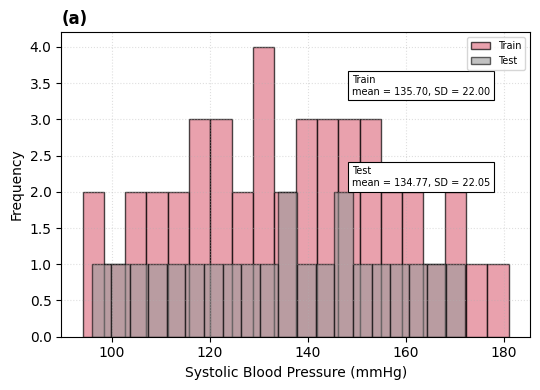

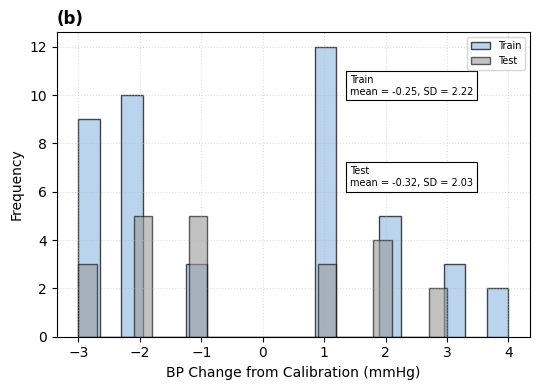

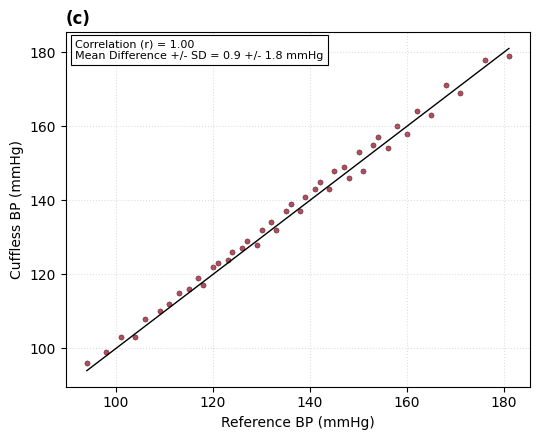

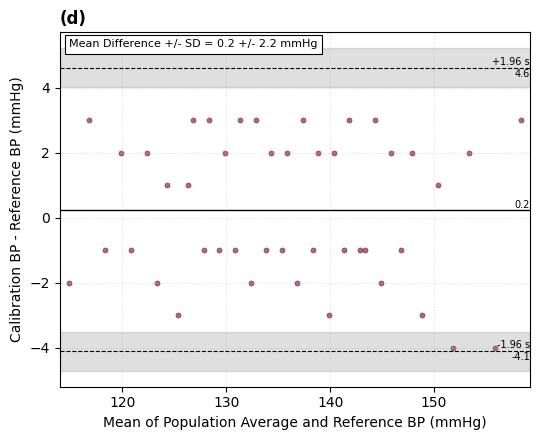

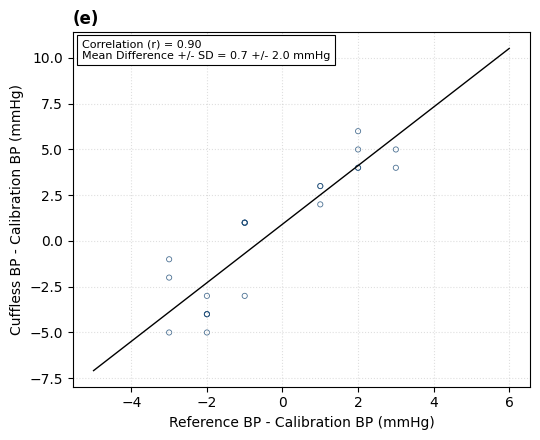

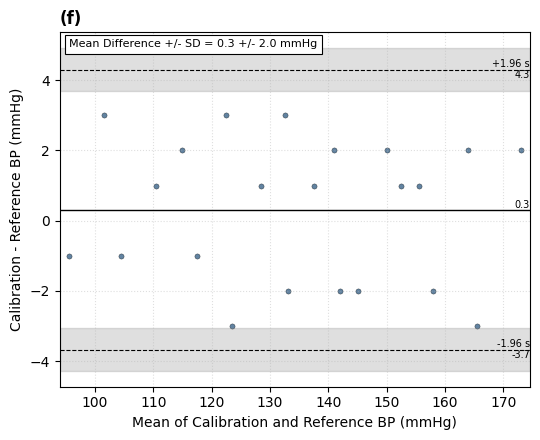

In [ ]:
# BP-Card figure generation from CSV files
import pandas as pd
from bp_card_figures import (
    FigureStyle,
    load_bp_card_data_from_csv,
    make_a_figure,
    make_b_figure,
    make_c_figure,
    make_d_figure,
    make_e_figure,
    make_f_figure,
    save_bp_card_figures,
    performance_reporting_table_from_csv,
    save_performance_table_csv,
    DEFAULT_CONDITION_ORDER,
)

# Choose one CSV input.
# Calibration-based CSV columns: split, reference_bp, prediction_bp, calibration_bp
# Calibration-free CSV columns:  split, reference_bp, prediction_bp
csv_path = "data/calibration_based_bp.csv"
mode = "calibration_based"

# For calibration-free data, use these instead:
# csv_path = "data/calibration_free_bp.csv"
# mode = "calibration_free"

data = load_bp_card_data_from_csv(csv_path, mode=mode)

# Optional shared style. Change colors once here.
style = FigureStyle(
    prediction_color="#a31f34",
    calibration_color="#1f4e79",
    train_hist_color="#e07a8b",
    change_hist_color="#9dc3e6",
    test_hist_color="#9a9a9a",
)

# Build individual panels when you want to inspect them in the notebook.
fig_a = make_a_figure(data, style=style)
fig_b = make_b_figure(data, style=style)
fig_c = make_c_figure(data, style=style)
fig_d = make_d_figure(data, style=style)
fig_e = make_e_figure(data, style=style)
fig_f = make_f_figure(data, style=style)

# Save all panels as separate files: fig_a.png, fig_b.png, ..., fig_f.png.
saved_paths = save_bp_card_figures(data, output_dir=".", prefix="fig", style=style)
saved_paths

# Standardized performance reporting table for calibration-free data.
# The group labels are read from the CSV; they are not calculated here.
calibration_free_table_rows = performance_reporting_table_from_csv(
    "data/calibration_free_bp.csv",
    mode="calibration_free",
    group_col="group",
)
calibration_free_table_path = save_performance_table_csv(
    calibration_free_table_rows,
    "calibration_free_performance_table.csv",
)
calibration_free_performance_table = pd.DataFrame(table_rows)
calibration_free_performance_table


# Standardized performance reporting table for calibration-based data.
# The condition labels are read from the CSV; they are not calculated here.
calibration_based_table_rows = performance_reporting_table_from_csv(
    "data/calibration_based_bp.csv",
    mode="calibration_based",
    group_col="condition",
    group_order=DEFAULT_CONDITION_ORDER,
    include_empty_groups=True,
)
calibration_based_table_path = save_performance_table_csv(
    calibration_based_table_rows,
    "calibration_based_performance_table.csv",
)
calibration_based_performance_table = pd.DataFrame(calibration_based_table_rows)
calibration_based_performance_table


In [11]:
performance_table

,Group,DeltaBP+/-SD (mmHg),MD+/-SD (mmHg),MAD (mmHg),MAPD (%),CP5 (%),CP10 (%),CP15 (%),R
0,All,-0.00 +/- 21.85,0.82 +/- 1.81,1.85,1.35,100.0,100.0,100.0,0.997
1,Normal,-0.00 +/- 7.84,1.24 +/- 0.75,1.35,1.26,100.0,100.0,100.0,0.996
2,Prehypertension,0.00 +/- 5.99,1.15 +/- 1.39,1.65,1.28,100.0,100.0,100.0,0.974
3,Hypertension Stage 1,-0.00 +/- 5.80,0.84 +/- 2.06,2.11,1.41,100.0,100.0,100.0,0.942
4,Hypertension Stage 2,0.00 +/- 6.59,-0.60 +/- 2.72,2.60,1.54,100.0,100.0,100.0,0.924
